In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Carga de datos

In [166]:
df = pd.read_csv('netflix_titles.csv', parse_dates=['date_added'], dayfirst=True)

df.head()

C:\Users\Miguel Angel\AppData\Local\Temp\ipykernel_19652\1285293283.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('netflix_titles.csv', parse_dates=['date_added'], dayfirst=True)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [167]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


## Renombre de columnas a espaniol

In [169]:
df_tratado = df.copy()

In [170]:
df_tratado.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [171]:
df_tratado.columns = ['id', 'tipo', 'titulo', 'director', 'elenco', 'pais', 'fecha_disponibilzacion',
       'anio_lanzamiento', 'clasificacion', 'duracion', 'genero', 'descripcion']

In [172]:
df_tratado.columns

Index(['id', 'tipo', 'titulo', 'director', 'elenco', 'pais',
       'fecha_disponibilzacion', 'anio_lanzamiento', 'clasificacion',
       'duracion', 'genero', 'descripcion'],
      dtype='str')

In [173]:
df_tratado.head()

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Valores faltantes

In [174]:
filas, columnas = df_tratado.shape

In [175]:
print(f"El DataFrame tiene {filas} filas y {columnas} columnas.")

El DataFrame tiene 8807 filas y 12 columnas.


In [176]:
df_tratado.isna().sum()

id                           0
tipo                         0
titulo                       0
director                  2634
elenco                     825
pais                       831
fecha_disponibilzacion      10
anio_lanzamiento             0
clasificacion                4
duracion                     3
genero                       0
descripcion                  0
dtype: int64

In [177]:
(df_tratado.isna().sum() / filas) * 100

id                         0.000000
tipo                       0.000000
titulo                     0.000000
director                  29.908028
elenco                     9.367549
pais                       9.435676
fecha_disponibilzacion     0.113546
anio_lanzamiento           0.000000
clasificacion              0.045418
duracion                   0.034064
genero                     0.000000
descripcion                0.000000
dtype: float64

In [178]:
for columna, nulo in df_tratado.isna().sum().items():
    if nulo > 0:
        porcentaje = (nulo / filas) * 100
        print(f"Columna: {columna}, Porcentaje de valores nulos: {porcentaje:.2f}%")

Columna: director, Porcentaje de valores nulos: 29.91%
Columna: elenco, Porcentaje de valores nulos: 9.37%
Columna: pais, Porcentaje de valores nulos: 9.44%
Columna: fecha_disponibilzacion, Porcentaje de valores nulos: 0.11%
Columna: clasificacion, Porcentaje de valores nulos: 0.05%
Columna: duracion, Porcentaje de valores nulos: 0.03%


## Peliculas y series disponibles

In [179]:
df_tratado['tipo'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [180]:
df_tratado['tipo'].value_counts()

tipo
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [181]:
df_tratado['tipo'].value_counts(normalize=True) * 100

tipo
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribución por Tipo'}>

<Axes: title={'center': 'Distribución por Tipo'}>

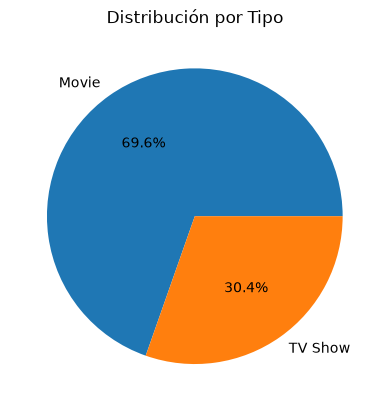

In [182]:
df_tratado['tipo'].value_counts().plot(kind='pie', title='Distribución por Tipo', autopct='%1.1f%%', colors=['#1f77b4', '#ff7f0e'])

## Conteo de registros con paises nulos

In [183]:
df_tratado.head()

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [184]:
df_tratado["pais"].isna()

0       False
1       False
2        True
3        True
4       False
        ...  
8802    False
8803     True
8804    False
8805    False
8806    False
Name: pais, Length: 8807, dtype: bool

In [185]:
df_sin_pais = df_tratado.loc[df_tratado["pais"].isna()].copy()

In [186]:
fila, columnas = df_sin_pais.shape
print(f"Hay {fila} registros sin país del DataFrame original.")

Hay 831 registros sin país del DataFrame original.


In [187]:
df_sin_pais["tipo"].value_counts()

tipo
Movie      440
TV Show    391
Name: count, dtype: int64

<Axes: title={'center': 'Distribución de tipos en registros sin país'}, xlabel='tipo'>

<Axes: title={'center': 'Distribución de tipos en registros sin país'}, xlabel='tipo'>

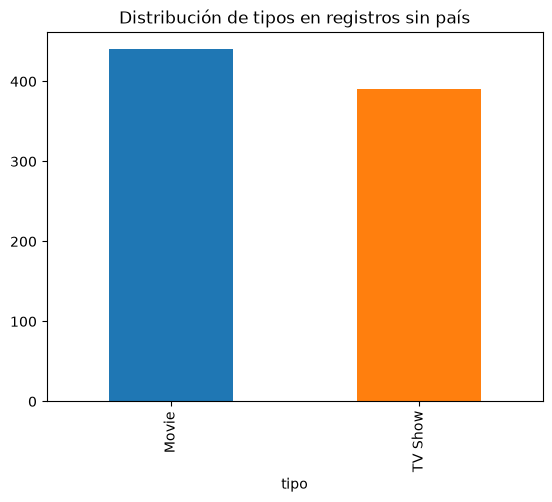

In [188]:
df_sin_pais["tipo"].value_counts().plot(kind="bar", title="Distribución de tipos en registros sin país", color=['#1f77b4', '#ff7f0e'])

C:\Users\Miguel Angel\AppData\Local\Temp\ipykernel_19652\838266022.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sin_pais["tipo"].value_counts().index, y=df_sin_pais["tipo"].value_counts().values, palette=['#1f77b4', '#ff7f0e'])


<Axes: xlabel='tipo'>

C:\Users\Miguel Angel\AppData\Local\Temp\ipykernel_19652\838266022.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sin_pais["tipo"].value_counts().index, y=df_sin_pais["tipo"].value_counts().values, palette=['#1f77b4', '#ff7f0e'])


<Axes: xlabel='tipo'>

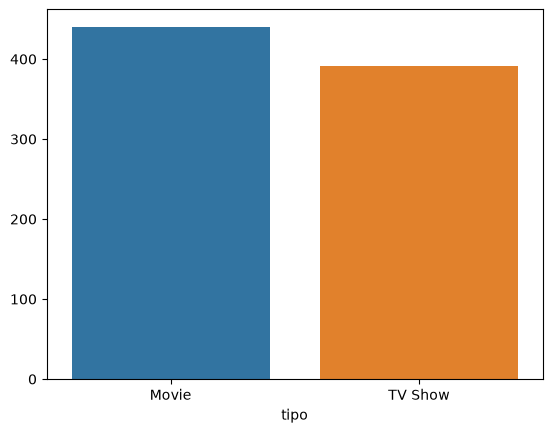

In [189]:
sns.barplot(x=df_sin_pais["tipo"].value_counts().index, y=df_sin_pais["tipo"].value_counts().values, palette=['#1f77b4', '#ff7f0e'])

## Fecha de estreno de la primera película 

In [190]:
df_movie = df_tratado.loc[df_tratado["tipo"] == "Movie"].copy()

In [191]:
df_movie.head()

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [192]:
df_movie["fecha_disponibilzacion"].min()

Timestamp('2008-01-01 00:00:00')

In [193]:
filtro = df_movie["fecha_disponibilzacion"] == df_movie["fecha_disponibilzacion"].min()
df_movie.loc[filtro]

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
5957,s5958,Movie,To and From New York,Sorin Dan Mihalcescu,"Barbara King, Shaana Diya, John Krisiukenas, Y...",United States,2008-01-01,2006,TV-MA,81 min,"Dramas, Independent Movies, Thrillers","While covering a story in New York City, a Sea..."


In [194]:
print(f"La fecha de disponibilidad más antigua para películas en Netflix es: {df_movie["fecha_disponibilzacion"].min().date()}, el titulo de la película es: {df_movie.loc[filtro, 'titulo'].values[0]}. El país de origen de la película es: {df_movie.loc[filtro, 'pais'].values[0]}.")

La fecha de disponibilidad más antigua para películas en Netflix es: 2008-01-01, el titulo de la película es: To and From New York. El país de origen de la película es: United States.


## Director con mas películas o series

In [195]:
df_tratado["director"].value_counts()

director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Peter Hewitt                1
Mozez Singh                 1
Name: count, Length: 4528, dtype: int64

In [196]:
df_tratado['director'].value_counts().idxmax()

'Rajiv Chilaka'

In [197]:
df_tratado[df_tratado["director"] == df_tratado['director'].value_counts().idxmax()]

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
406,s407,Movie,Chhota Bheem - Neeli Pahaadi,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,Things get spooky when Bheem and his buddies t...
407,s408,Movie,Chhota Bheem & Ganesh,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,Bheem and Lord Ganesha join forces to save Dho...
408,s409,Movie,Chhota Bheem & Krishna: Mayanagari,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2011,TV-Y7,67 min,Children & Family Movies,Young lord Krishna has fallen for demoness Maa...
409,s410,Movie,Chhota Bheem & Krishna: Pataliputra- City of t...,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2010,TV-Y7,66 min,Children & Family Movies,Krishna needs Bheem’s help: The ruined city of...
410,s411,Movie,Chhota Bheem And The Broken Amulet,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,When a stranger tries to steal an amulet from ...
411,s412,Movie,Chhota Bheem And The Crown of Valhalla,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,To save the kingdom of Valhalla from invasion ...
412,s413,Movie,Chhota Bheem and the Incan Adventure,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,65 min,Children & Family Movies,"When Dholakpur’s princess is kidnapped, Bheem ..."
413,s414,Movie,Chhota Bheem and The ShiNobi Secret,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,After learning of a samurai village under thre...
414,s415,Movie,Chhota Bheem Aur Hanuman,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2012,TV-Y7,68 min,Children & Family Movies,When two evil entities kidnap a princess in a ...
415,s416,Movie,Chhota Bheem aur Krishna,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,"Centuries after the end of a conqueror's rule,..."


In [198]:
df_tratado.query('director == "Rajiv Chilaka"')

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
406,s407,Movie,Chhota Bheem - Neeli Pahaadi,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,Things get spooky when Bheem and his buddies t...
407,s408,Movie,Chhota Bheem & Ganesh,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,Bheem and Lord Ganesha join forces to save Dho...
408,s409,Movie,Chhota Bheem & Krishna: Mayanagari,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2011,TV-Y7,67 min,Children & Family Movies,Young lord Krishna has fallen for demoness Maa...
409,s410,Movie,Chhota Bheem & Krishna: Pataliputra- City of t...,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2010,TV-Y7,66 min,Children & Family Movies,Krishna needs Bheem’s help: The ruined city of...
410,s411,Movie,Chhota Bheem And The Broken Amulet,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,When a stranger tries to steal an amulet from ...
411,s412,Movie,Chhota Bheem And The Crown of Valhalla,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,To save the kingdom of Valhalla from invasion ...
412,s413,Movie,Chhota Bheem and the Incan Adventure,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,65 min,Children & Family Movies,"When Dholakpur’s princess is kidnapped, Bheem ..."
413,s414,Movie,Chhota Bheem and The ShiNobi Secret,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,After learning of a samurai village under thre...
414,s415,Movie,Chhota Bheem Aur Hanuman,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2012,TV-Y7,68 min,Children & Family Movies,When two evil entities kidnap a princess in a ...
415,s416,Movie,Chhota Bheem aur Krishna,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,"Centuries after the end of a conqueror's rule,..."


In [199]:
print(f"El director con más películas en Netflix es: {df_tratado['director'].value_counts().idxmax()}, con un total de {df_tratado['director'].value_counts().max()} películas. Su país de origen es India")

El director con más películas en Netflix es: Rajiv Chilaka, con un total de 19 películas. Su país de origen es India


## Pelicula mas larga y mas corta

In [200]:
df_movie.loc[df_movie["duracion"].isna()].shape[0]

3

In [201]:
df_movie.loc[[5541, 5794, 5813], "duracion"] = ["74 min", "84 min", "66 min"]

In [202]:
df_movie["duracion"]

0        90 min
6        91 min
7       125 min
9       104 min
12      127 min
         ...   
8801     96 min
8802    158 min
8804     88 min
8805     88 min
8806    111 min
Name: duracion, Length: 6131, dtype: str

In [203]:
df_movie.loc[[5541, 5794, 5813], "clasificacion"] = np.nan

In [204]:
df_movie.loc[[5541, 5794, 5813]]

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...


In [205]:
df_movie["duracion_min"] = df_movie["duracion"].str.replace(" min", "").astype(int)

In [206]:
df_movie.head()

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion,duracion_min
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127


In [207]:
df_movie["duracion_min"].max()

np.int64(312)

In [208]:
df_movie.query('duracion_min == @df_movie["duracion_min"].max()')

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion,duracion_min
4253,s4254,Movie,Black Mirror: Bandersnatch,NaN,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",312


El dataset presenta irregularidades con la realidad, por tanto se indaga profundamente en los datos para encontrar la pelicula de mayor duranción real

### Mayor duración

In [209]:
df_movie["duracion_min"].sort_values(ascending=False).head(10)

4253    312
717     273
2491    253
2487    237
2484    233
2488    230
166     229
7932    228
1019    224
4573    214
Name: duracion_min, dtype: int64

In [210]:
df_movie.loc[717]

id                                                                     s718
tipo                                                                  Movie
titulo                                          Headspace: Unwind Your Mind
director                                                                NaN
elenco                    Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...
pais                                                                    NaN
fecha_disponibilzacion                                  2021-06-15 00:00:00
anio_lanzamiento                                                       2021
clasificacion                                                          TV-G
duracion                                                            273 min
genero                                                        Documentaries
descripcion               Do you want to relax, meditate or sleep deeply...
duracion_min                                                            273
Name: 717, d

In [211]:
df_movie.loc[2491]

id                                                                    s2492
tipo                                                                  Movie
titulo                                               The School of Mischief
director                                             Houssam El-Din Mustafa
elenco                    Suhair El-Babili, Adel Emam, Saeed Saleh, Youn...
pais                                                                  Egypt
fecha_disponibilzacion                                  2020-05-21 00:00:00
anio_lanzamiento                                                       1973
clasificacion                                                         TV-14
duracion                                                            253 min
genero                               Comedies, Dramas, International Movies
descripcion               A high school teacher volunteers to transform ...
duracion_min                                                            253
Name: 2491, 

### Menor duración

In [212]:
df_movie["duracion_min"].sort_values(ascending=True).head(10)

3777     3
2713     5
1484     8
1557     9
3535    10
2858    11
6405    11
695     12
3775    12
4707    12
Name: duracion_min, dtype: int64

In [213]:
df_movie.loc[3777]

id                                                                    s3778
tipo                                                                  Movie
titulo                                                               Silent
director                                  Limbert Fabian, Brandon Oldenburg
elenco                                                                  NaN
pais                                                          United States
fecha_disponibilzacion                                  2019-06-04 00:00:00
anio_lanzamiento                                                       2014
clasificacion                                                          TV-Y
duracion                                                              3 min
genero                           Children & Family Movies, Sci-Fi & Fantasy
descripcion               "Silent" is an animated short film created by ...
duracion_min                                                              3
Name: 3777, 

In [214]:
print(f"La peliculas con mas duracion es: {df_movie.loc[2491, 'titulo']}, con una duracion de {df_movie.loc[2491, 'duracion_min']} minutos.")
print(f"La peliculas con menos duracion es: {df_movie.loc[3777, 'titulo']}, con una duracion de {df_movie.loc[3777, 'duracion_min']} minutos.")

La peliculas con mas duracion es: The School of Mischief, con una duracion de 253 minutos.
La peliculas con menos duracion es: Silent, con una duracion de 3 minutos.


## Promedio de duración de películas

Analizar primero los outliners (datos atípicos)

<Axes: xlabel='duracion_min'>

<Axes: xlabel='duracion_min'>

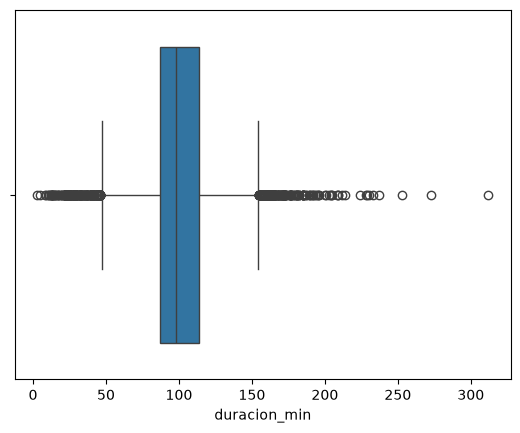

In [215]:
sns.boxplot(x=df_movie["duracion_min"], color="#1f77b4")

In [216]:
df_movie["duracion_min"].sort_values(ascending=False)

4253    312
717     273
2491    253
2487    237
2484    233
       ... 
3535     10
1557      9
1484      8
2713      5
3777      3
Name: duracion_min, Length: 6131, dtype: int64

In [217]:
df_movie.loc[4253, "duracion_min"] = 90

In [218]:
df_movie.loc[4253]

id                                                                    s4254
tipo                                                                  Movie
titulo                                           Black Mirror: Bandersnatch
director                                                                NaN
elenco                    Fionn Whitehead, Will Poulter, Craig Parkinson...
pais                                                          United States
fecha_disponibilzacion                                  2018-12-28 00:00:00
anio_lanzamiento                                                       2018
clasificacion                                                         TV-MA
duracion                                                            312 min
genero                       Dramas, International Movies, Sci-Fi & Fantasy
descripcion               In 1984, a young programmer begins to question...
duracion_min                                                             90
Name: 4253, 

In [219]:
df_movie.loc[717, "duracion_min"] = 15

In [220]:
df_movie.loc[717]

id                                                                     s718
tipo                                                                  Movie
titulo                                          Headspace: Unwind Your Mind
director                                                                NaN
elenco                    Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...
pais                                                                    NaN
fecha_disponibilzacion                                  2021-06-15 00:00:00
anio_lanzamiento                                                       2021
clasificacion                                                          TV-G
duracion                                                            273 min
genero                                                        Documentaries
descripcion               Do you want to relax, meditate or sleep deeply...
duracion_min                                                             15
Name: 717, d

<Axes: xlabel='duracion_min'>

<Axes: xlabel='duracion_min'>

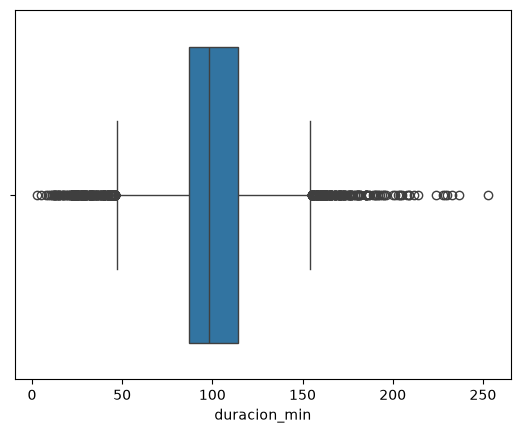

In [221]:
sns.boxplot(x=df_movie["duracion_min"], color="#1f77b4")

In [222]:
df_movie["duracion_min"].describe()

count    6131.000000
mean       99.486707
std        28.092749
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       253.000000
Name: duracion_min, dtype: float64

In [223]:
round(df_movie["duracion_min"].mean(), 1)

np.float64(99.5)

In [224]:
print(f"El tiempo promedio de duración de las películas en Netflix es de {round(df_movie['duracion_min'].mean(), 1)} minutos.")

El tiempo promedio de duración de las películas en Netflix es de 99.5 minutos.


## Paises que producen mas series y programas de TV

In [225]:
df_tratado.isnull().sum()

id                           0
tipo                         0
titulo                       0
director                  2634
elenco                     825
pais                       831
fecha_disponibilzacion      10
anio_lanzamiento             0
clasificacion                4
duracion                     3
genero                       0
descripcion                  0
dtype: int64

In [226]:
df_tratado.loc[df_tratado["tipo"] == "TV Show", "pais"].value_counts(dropna=False)

pais
United States                                     760
NaN                                               391
United Kingdom                                    213
Japan                                             169
South Korea                                       158
                                                 ... 
Ireland, Canada, United States, United Kingdom      1
Germany, United States, Italy                       1
United Kingdom, United States, Czech Republic       1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
Name: count, Length: 197, dtype: int64

In [227]:
print(f"Los 3 países con más series de TV en Netflix son: {df_tratado.loc[df_tratado['tipo'] == 'TV Show', 'pais'].value_counts().head(3).to_dict()}.")

Los 3 países con más series de TV en Netflix son: {'United States': 760, 'United Kingdom': 213, 'Japan': 169}.


## Anio de estreno de mas cantidad de peliculas y series colombianas estrenadas

In [228]:
len(df_tratado.loc[df_tratado["pais"].str.contains("Colombia")])

52

In [229]:
df_tratado_colombia = df_tratado.loc[df_tratado["pais"].str.contains("Colombia")].copy()

In [230]:
df_tratado_colombia.head()

,id,tipo,titulo,director,elenco,pais,fecha_disponibilzacion,anio_lanzamiento,clasificacion,duracion,genero,descripcion
278,s279,Movie,Lokillo: Nothing's the Same,Julián Gaviria,Lokillo Florez,Colombia,2021-08-12,2021,TV-MA,64 min,Stand-Up Comedy,"Through songs and puns, comedian Lokillo Flore..."
288,s289,TV Show,Las muñecas de la mafia,NaN,"Amparo Grisales, Fernando Solórzano, Angelica ...",Colombia,2021-08-10,2018,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...","Based on the book ""Las Fantásticas,"" this exci..."
744,s745,TV Show,Locombianos,NaN,"Freddy Beltrán, Pamela Ospina, Diego Camargo, ...",Colombia,2021-06-10,2021,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...",Four of Colombia's funniest and bawdiest comed...
750,s751,Movie,Tragic Jungle,Yulene Olaizola,"Indira Andrewin, Gilberto Barraza, Gabino Rodr...","Mexico, France, Colombia",2021-06-09,2021,TV-MA,97 min,"Dramas, Independent Movies, International Movies","To escape an arranged marriage, a woman flees ..."
753,s754,TV Show,"Newly Rich, Newly Poor",NaN,"Martín Karpan, Carolina Acevedo, Jhon Álex Tor...",Colombia,2021-06-06,2007,TV-MA,1 Season,"International TV Shows, Romantic TV Shows, Spa...","After learning they were switched at birth, we..."


In [231]:
df_tratado_colombia["fecha_disponibilzacion"].dt.year.value_counts()

fecha_disponibilzacion
2018    15
2019    12
2020    10
2021     9
2017     4
2016     2
Name: count, dtype: int64

<Axes: title={'center': 'Distribución de títulos por año de disponibilidad en Colombia'}, xlabel='fecha_disponibilzacion'>

<Axes: title={'center': 'Distribución de títulos por año de disponibilidad en Colombia'}, xlabel='fecha_disponibilzacion'>

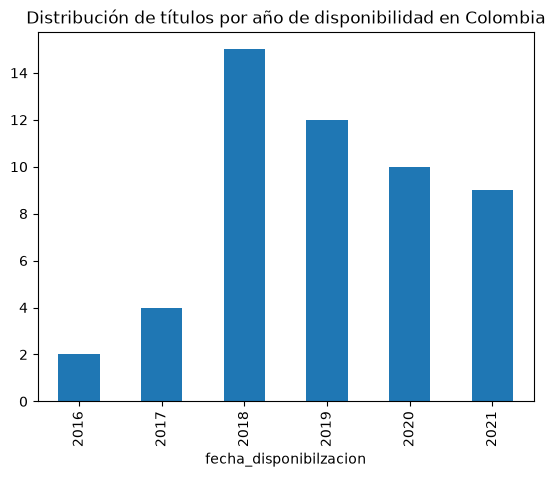

In [233]:
df_tratado_colombia["fecha_disponibilzacion"].dt.year.value_counts().sort_index().plot(kind="bar", title="Distribución de títulos por año de disponibilidad en Colombia", color="#1f77b4")

In [234]:
print(f"El anio en que mas cantidad de peliculas y series colombianas fueron agregadas a Netflix es: {df_tratado_colombia['fecha_disponibilzacion'].dt.year.value_counts().idxmax()}, con un total de {df_tratado_colombia['fecha_disponibilzacion'].dt.year.value_counts().max()} títulos.")

El anio en que mas cantidad de peliculas y series colombianas fueron agregadas a Netflix es: 2018, con un total de 15 títulos.


## Directores colombianos con mas películas y series

In [235]:
df_tratado_colombia["director"].value_counts()

director
Fernando Ayllón                                      4
Alessandro Angulo                                    2
Raúl Campos, Jan Suter                               2
Julián Gaviria                                       1
Yulene Olaizola                                      1
Carlos Moreno                                        1
Juan Camilo Pinzon                                   1
Peter Berg                                           1
Kate Horne                                           1
Luis Alberto Restrepo, Andrés Beltrán, Jaime Rayo    1
Rodrigo Triana                                       1
Peter Webber                                         1
Hatem Khraiche                                       1
Juan Zapata                                          1
Alejandro Lozano                                     1
Jorge Granier                                        1
Name: count, dtype: int64

In [236]:
print(f"El director colombiano con más títulos en Netflix es: {df_tratado_colombia['director'].value_counts().idxmax()}, con un total de {df_tratado_colombia['director'].value_counts().max()} títulos.")

El director colombiano con más títulos en Netflix es: Fernando Ayllón, con un total de 4 títulos.


## Diferencias entre clasificaciones

In [237]:
df_tratado["clasificacion"].value_counts()

clasificacion
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [238]:
df_tratado["clasificacion"].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR']
Length: 18, dtype: str

In [240]:
clasificaciones_ninos = [
    'PG',
    'PG-13',
    'TV-G',
    'TV-PG',
    'TV-Y',
    'TV-Y7',
    'TV-Y7-FV',
    'TV-14'
]

clasificaciones_adolescentes_adultos = [
    'TV-MA',
    'R',
    'NC-17'
]

clasificaciones_ninos, clasificaciones_adolescentes_adultos

(['PG', 'PG-13', 'TV-G', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-14'],
 ['TV-MA', 'R', 'NC-17'])